# Fully-Connected Autoencoder with 2 dimensional Latent Space

A small fully-connected autoencoder on MNIST with a **2-dimensional bottleneck**.
The whole latent space fits on a 2D plot, so we can visualize it directly:

1. Train encoder $\mathbb{R}^{784} \to \mathbb{R}^2$ and decoder $\mathbb{R}^2 \to \mathbb{R}^{784}$.
2. Plot all test latents as a scatter colored by digit class.
3. Sample from a regular grid in latent space and decode
4. Compare with random Gaussian samples to show unrealistic results

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
LATENT_DIM = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
to_tensor = transforms.ToTensor()
train_ds = datasets.MNIST("data", train=True, download=True, transform=to_tensor)
test_ds = datasets.MNIST("data", train=False, download=True, transform=to_tensor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 11.3MB/s]


Train: 60000, Test: 10000


## 1. Model: Fully-Connected Autoencoder

- Encoder: 784 → 256 → 64 → **2**
- Decoder: **2** → 64 → 256 → 784 (sigmoid)

In [4]:
class FCAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 28 * 28), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z

model = FCAutoencoder(LATENT_DIM).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
x = torch.randn(1, 1, 28, 28).to(device)
out, z = model(x)
print(f"Input: {x.shape}  ->  Latent: {z.shape}  ->  Output: {out.shape}")

Parameters: 435,858
Input: torch.Size([1, 1, 28, 28])  ->  Latent: torch.Size([1, 2])  ->  Output: torch.Size([1, 1, 28, 28])


## 2. Train

In [5]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train": [], "val": []}
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images = images.to(device)
        recon, _ = model(images)
        loss = criterion(recon, images)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            recon, _ = model(images)
            val_loss += criterion(recon, images).item()

    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

torch.save(model.state_dict(), "fc_autoencoder_2d.pth")
print("Saved to fc_autoencoder_2d.pth")

Epoch 1: Train Loss=0.2648, Val Loss=0.2247


Epoch 2: Train Loss=0.2182, Val Loss=0.2091


Epoch 3: Train Loss=0.2030, Val Loss=0.1985


Epoch 4: Train Loss=0.1966, Val Loss=0.1937


Epoch 5: Train Loss=0.1932, Val Loss=0.1909


...

Epoch 26: Train Loss=0.1733, Val Loss=0.1749


Epoch 27: Train Loss=0.1728, Val Loss=0.1747


Epoch 28: Train Loss=0.1726, Val Loss=0.1746


Epoch 29: Train Loss=0.1722, Val Loss=0.1741


Epoch 30: Train Loss=0.1718, Val Loss=0.1743
Saved to fc_autoencoder_2d.pth


## 3. Reconstruction Quality

With only 2 latent dimensions for ~10 digit classes, reconstructions might be
lossy — but recognizable digits should come out.

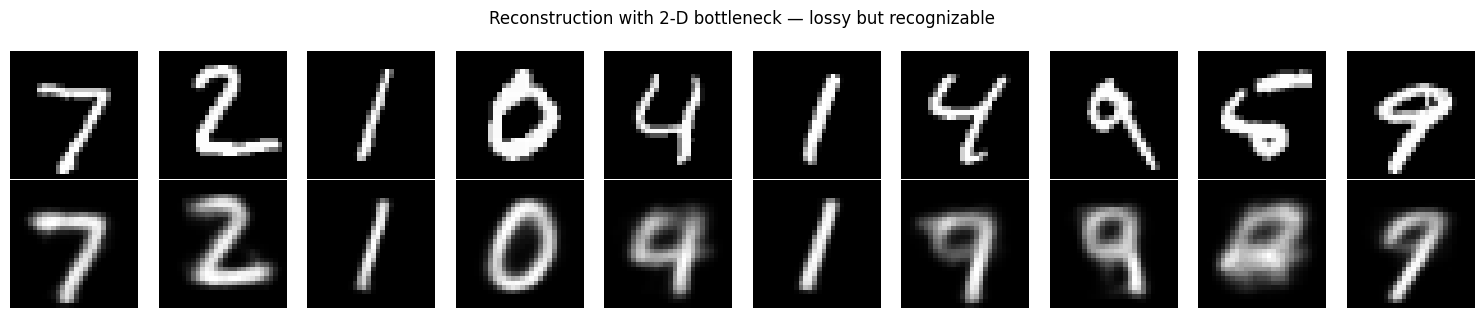

In [6]:
model.eval()
images, _ = next(iter(test_loader))
images = images[:10].to(device)
with torch.no_grad():
    recons, _ = model(images)

fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recons[i].cpu().squeeze(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruction", fontsize=11)
plt.suptitle(f"Reconstruction with {LATENT_DIM}-D bottleneck — lossy but recognizable", fontsize=12)
plt.tight_layout()
plt.show()

## 4. The 2D Latent Space

Encode the entire test set and plot each point colored by its digit class. Classes
naturally cluster, but the layout is irregular: e.g. gaps between clusters

Saved latents_ae_2d.npz


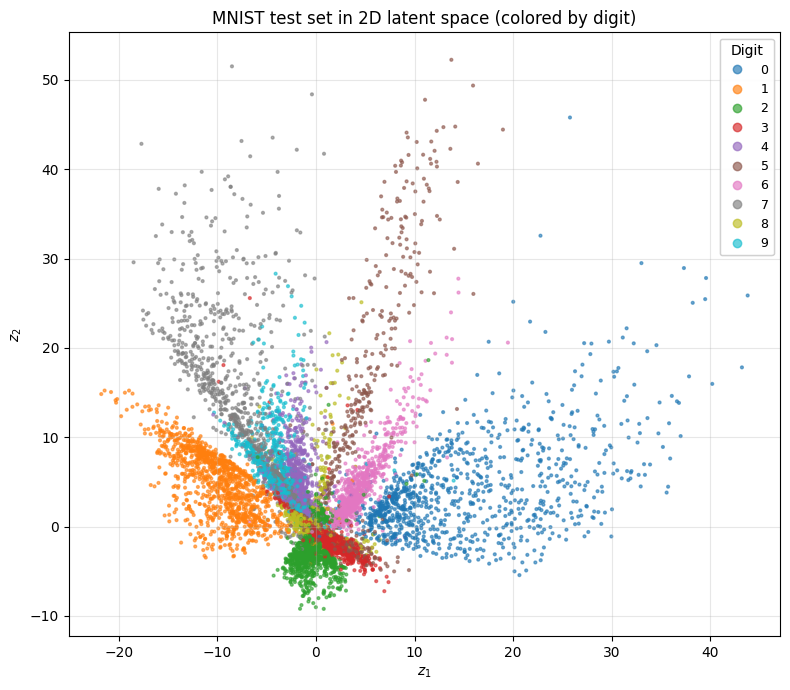

z1 range: [-21.77, 43.79]
z2 range: [-9.21, 52.26]


In [7]:
all_z, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        _, z = model(images.to(device))
        all_z.append(z.cpu()); all_labels.append(labels)
all_z = torch.cat(all_z).numpy()
all_labels = torch.cat(all_labels).numpy()

# Save for the VAE-vs-AE comparison in 02_VAE_2D
np.savez("latents_ae_2d.npz", z=all_z, labels=all_labels)
print("Saved latents_ae_2d.npz")

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap="tab10", s=4, alpha=0.6)
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("MNIST test set in 2D latent space (colored by digit)")
ax.grid(alpha=0.3)
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best", fontsize=9)
ax.add_artist(legend)
plt.tight_layout()
plt.show()

print(f"z1 range: [{all_z[:, 0].min():.2f}, {all_z[:, 0].max():.2f}]")
print(f"z2 range: [{all_z[:, 1].min():.2f}, {all_z[:, 1].max():.2f}]")

## 5. Decode a Grid in Latent Space

Uniform grid over region of the latent plane and decode each
point. This reveals the manifold the decoder has learned: digits morph into
each other.

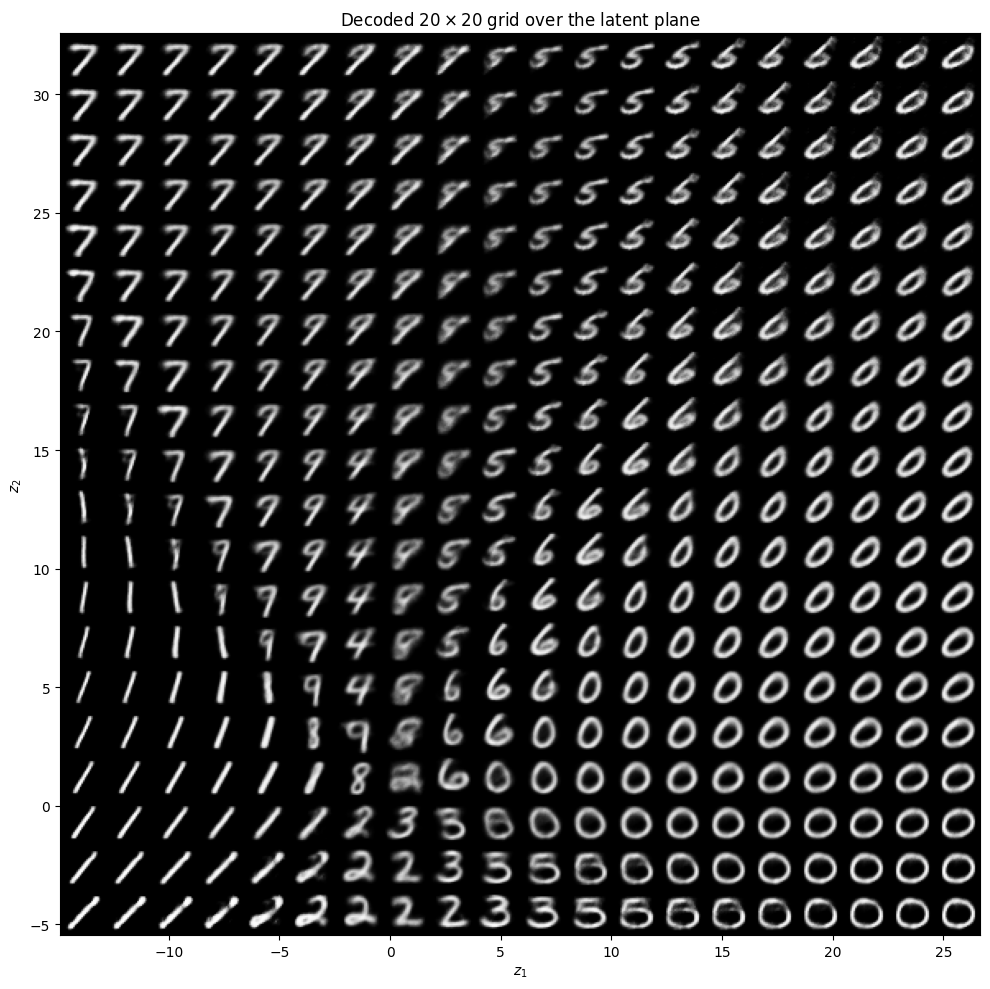

In [8]:
GRID = 20
# Use the percentile range so we don't sample far outside what the encoder produced
z1_min, z1_max = np.percentile(all_z[:, 0], [1, 99])
z2_min, z2_max = np.percentile(all_z[:, 1], [1, 99])

grid_z1 = np.linspace(z1_min, z1_max, GRID)
grid_z2 = np.linspace(z2_max, z2_min, GRID)  # reversed so y-axis points up

canvas = np.zeros((GRID * 28, GRID * 28))
with torch.no_grad():
    for i, z2 in enumerate(grid_z2):
        for j, z1 in enumerate(grid_z1):
            z = torch.tensor([[z1, z2]], dtype=torch.float32, device=device)
            img = model.decoder(z).view(28, 28).cpu().numpy()
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(canvas, cmap="gray",
          extent=[z1_min, z1_max, z2_min, z2_max],
          aspect="auto")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Decoded $20 \\times 20$ grid over the latent plane")
plt.tight_layout()
plt.show()

## 6. Real points on the manifold

Overlay the test-set scatter on top of the decoded grid. You can see digits appear in
the regions where their class actually lives.

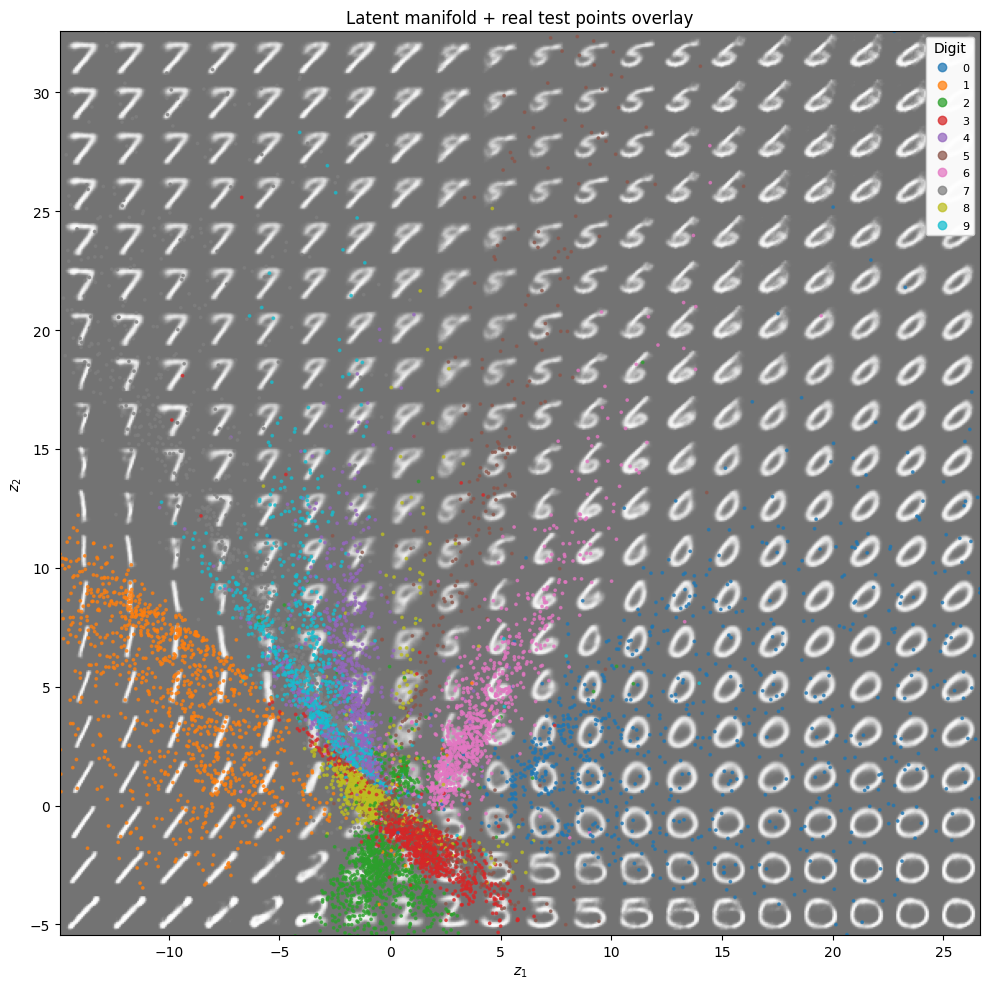

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(canvas, cmap="gray", extent=[z1_min, z1_max, z2_min, z2_max], aspect="auto", alpha=0.55)
scatter = ax.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap="tab10", s=3, alpha=0.7)
ax.set_xlim(z1_min, z1_max); ax.set_ylim(z2_min, z2_max)
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Latent manifold + real test points overlay")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best", fontsize=8)
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 7. Random Sampling

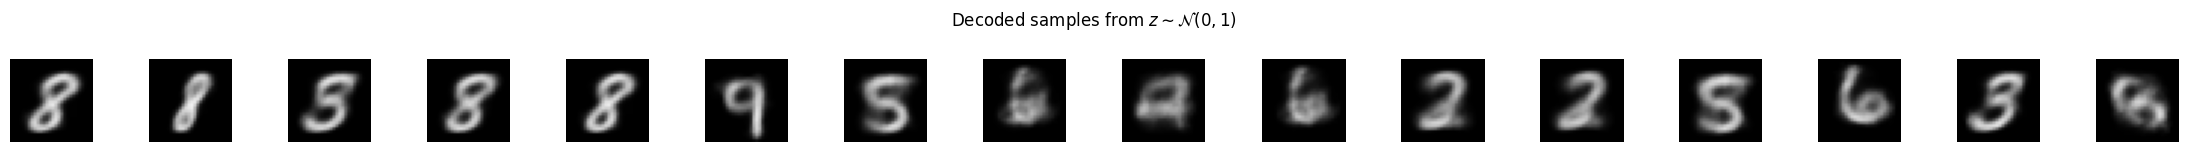

In [10]:
torch.manual_seed(0)
N = 16

z_gauss = torch.randn(N, LATENT_DIM, device=device)
with torch.no_grad():
    samples_gauss = model.decoder(z_gauss).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, N, figsize=(1.4 * N, 1.5))
for j in range(N):
    axes[j].imshow(samples_gauss[j], cmap="gray", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Decoded samples from $z \\sim \\mathcal{N}(0, 1)$", fontsize=12)
plt.tight_layout()
plt.show()

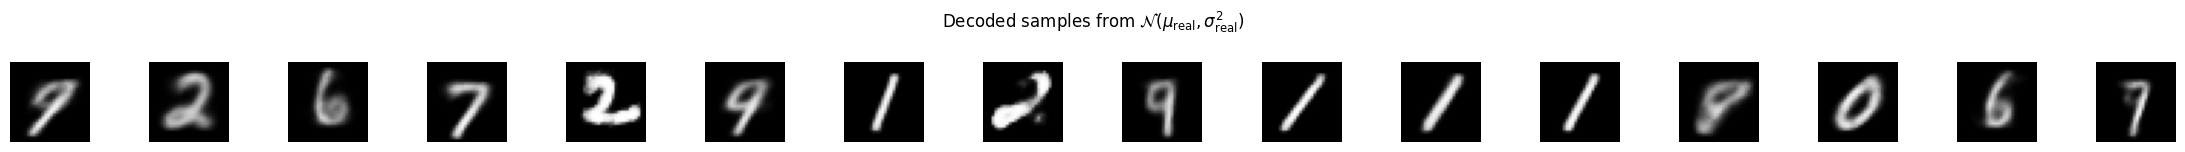

In [11]:
torch.manual_seed(1)

mu_real = torch.tensor(all_z.mean(axis=0), dtype=torch.float32, device=device)
sigma_real = torch.tensor(all_z.std(axis=0), dtype=torch.float32, device=device)
z_matched = mu_real + sigma_real * torch.randn(N, LATENT_DIM, device=device)

with torch.no_grad():
    samples_matched = model.decoder(z_matched).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, N, figsize=(1.4 * N, 1.5))
for j in range(N):
    axes[j].imshow(samples_matched[j], cmap="gray", vmin=0, vmax=1); axes[j].axis("off")
fig.suptitle("Decoded samples from $\\mathcal{N}(\\mu_{\\text{real}}, \\sigma_{\\text{real}}^2)$", fontsize=12)
plt.tight_layout()
plt.show()

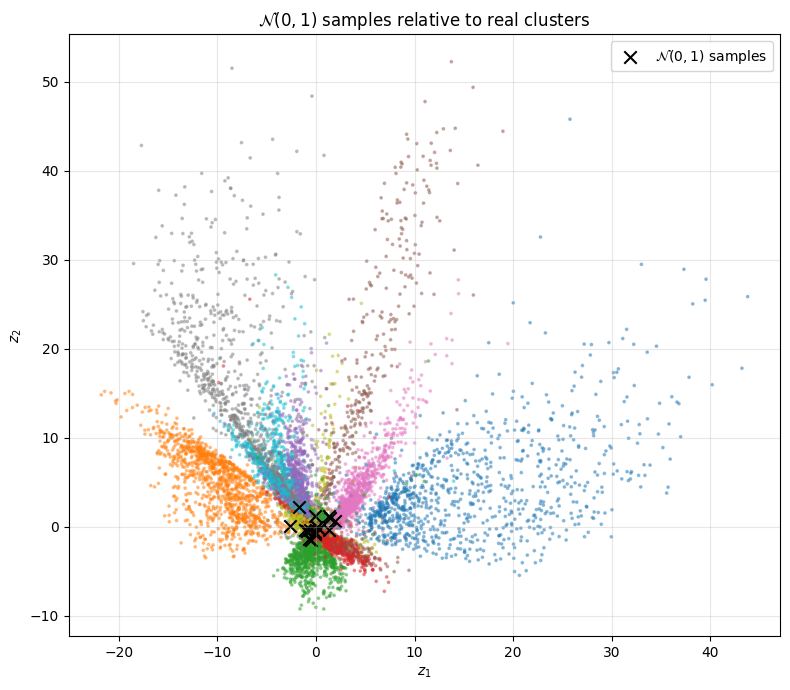

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap="tab10", s=3, alpha=0.4)
ax.scatter(z_gauss.cpu()[:, 0], z_gauss.cpu()[:, 1], c="black", s=80, marker="x",
           label="$\\mathcal{N}(0, 1)$ samples")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("$\\mathcal{N}(0, 1)$ samples relative to real clusters")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

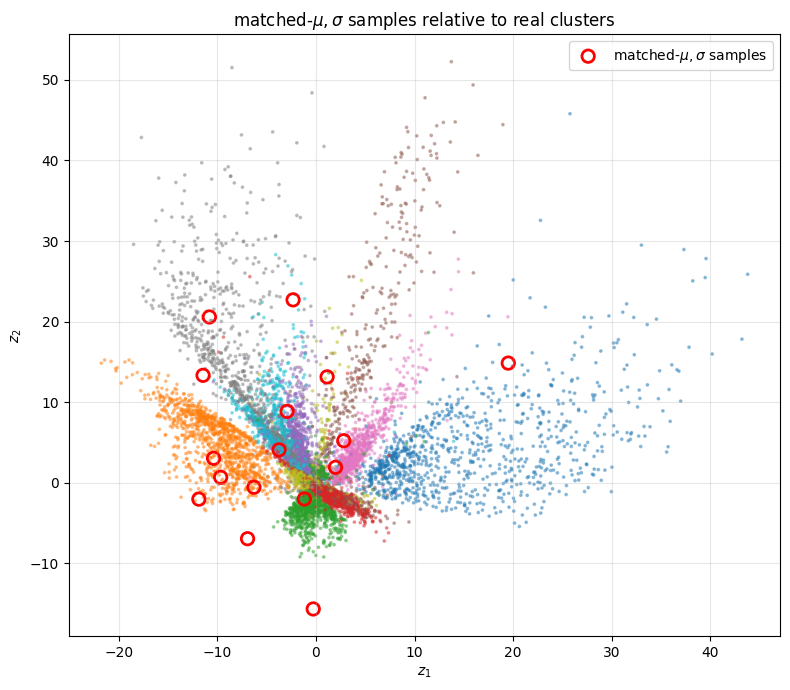

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap="tab10", s=3, alpha=0.4)
ax.scatter(z_matched.cpu()[:, 0], z_matched.cpu()[:, 1], facecolors="none", edgecolors="red",
           s=80, linewidths=2, label="matched-$\\mu, \\sigma$ samples")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("matched-$\\mu, \\sigma$ samples relative to real clusters")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaway

A 2D latent space lets us see the problem.

- The encoder has learned to push each digit class into a distinct cluster, but the
  arrangement is whatever was convenient for reconstruction.
- Sampling from random not really useful

A VAE replaces the irregular cluster layout with a Gaussian-shaped latent space by
construction (KL term), so $z \sim \mathcal{N}(0, I)$ samples land **inside** the
data distribution — not in the gaps.